In [1]:
import pandas as pd

In [2]:
train_df = pd.read_csv("Train_Data.csv")
len(train_df)

100000

In [3]:
train_df.columns

Index(['image_add', 'Class'], dtype='str')

In [4]:
test_df = pd.read_csv("Test_Data.csv")
len(test_df)

20000

In [5]:
import torch

In [6]:
from PIL import Image

In [7]:
mapper = {"FAKE" : 0 , "REAL" : 1}

In [8]:
train_df["Class"] = train_df["Class"].map(mapper)

In [9]:
test_df["Class"] = test_df["Class"].map(mapper)

In [58]:
class datasets():
    def __init__(self, transforms, df):
        self.t = transforms
        self.df = df

    def __getitem__(self, index):
        row = self.df.iloc[index]
        img = row["image_add"]
        img = self.t(Image.open(img))
        lab = row["Class"]
        lab = torch.tensor(lab, dtype=torch.int64)
        return img, lab

In [11]:
from torchvision.transforms import transforms

In [12]:
tester_trans_1 = transforms.Compose(transforms.ToTensor())
tester_trans_1 = transforms.Compose([transforms.Resize((256 , 256)) ,transforms.InterpolationMode.NEAREST , transforms.ToTensor()])

In [13]:
t1 = train_df["image_add"][100]

In [14]:
t1

'C:\\Dash_Strikes\\REAL_VS_AI\\DATA\\train\\FAKE\\1010 (10).jpg'

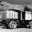

In [15]:
img = Image.open(t1)
img

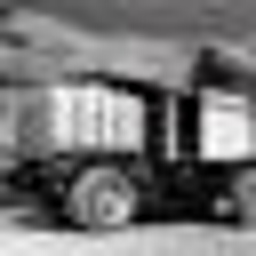

In [16]:
img.resize((256 , 256))

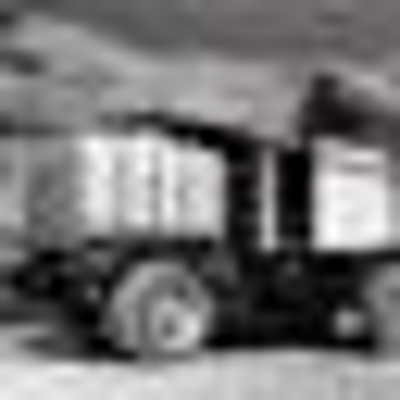

In [17]:
img.resize((400 , 400))

In [18]:
nearest = transforms.Resize( (256, 256), interpolation = transforms.InterpolationMode.NEAREST)
bilinear = transforms.Resize( (256, 256), interpolation = transforms.InterpolationMode.BILINEAR)
bicubic = transforms.Resize( (256, 256),  interpolation=transforms.InterpolationMode.BICUBIC)

In [19]:
img_nearest = nearest(img)
img_bilinear = bilinear(img)
img_bicubic = bicubic(img)

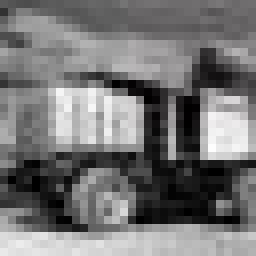

In [20]:
img_nearest

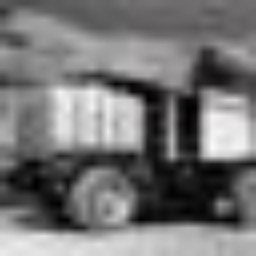

In [21]:
img_bilinear

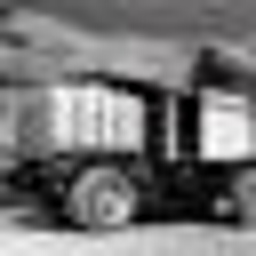

In [22]:
img_bicubic

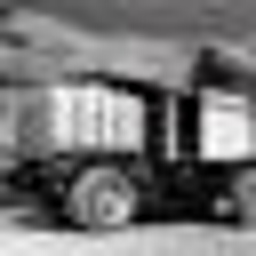

In [23]:
img.resize((256 , 256))

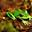

In [24]:
t3 = train_df["image_add"][106]
img1 = Image.open(t3)
img1

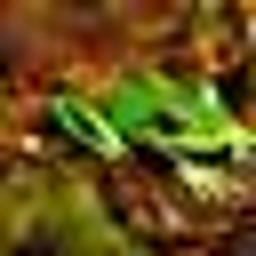

In [25]:
img1.resize((256 , 256))

In [26]:
img_nearest = nearest(img1)
img_bilinear = bilinear(img1)
img_bicubic = bicubic(img1)

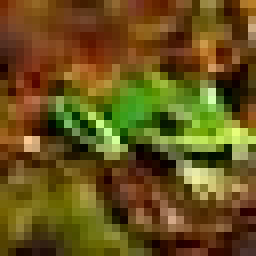

In [27]:
img_nearest

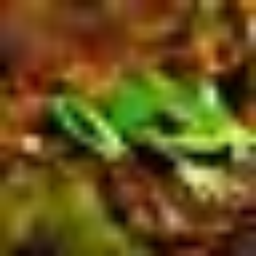

In [28]:
img_bilinear

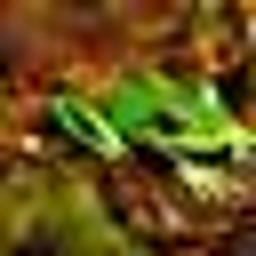

In [29]:
img_bicubic

In [31]:
trans_test_32 = transforms.ToTensor()
trans_test_256 = transforms.Compose([transforms.Resize((256, 256)),
                                     transforms.ToTensor()])

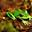

In [32]:
img1

In [35]:
img_t_32 = trans_test_32(img1)
img_t_32.shape

torch.Size([3, 32, 32])

In [37]:
r32_mean = torch.mean(img_t_32[0])
g32_mean = torch.mean(img_t_32[1])
b32_mean = torch.mean(img_t_32[2])

In [38]:
r32_std = torch.std(img_t_32[0])
g32_std = torch.std(img_t_32[1])
b32_std = torch.std(img_t_32[2])

In [41]:
img_t_256 = trans_test_256(img1)
img_t_256.shape

torch.Size([3, 256, 256])

In [42]:
r256_mean = torch.mean(img_t_256[0])
g256_mean = torch.mean(img_t_256[1])
b256_mean = torch.mean(img_t_256[2])

In [43]:
r256_std = torch.std(img_t_256[0])
g256_std = torch.std(img_t_256[1])
b256_std = torch.std(img_t_256[2])

## normal along with trivial augmentations

In [39]:
from torchvision.transforms import TrivialAugmentWide

## we will use the normal form (32 * 32) then to tensors then normalize

In [40]:
trans_1 = transforms.Compose([ TrivialAugmentWide(), transforms.ToTensor() ,
                               transforms.Normalize((r32_mean ,g32_mean ,b32_mean) 
                                                   , (r32_std ,g32_std ,b32_std))])

## we will resize to 256 * 256 ,  bicubic interpolation then to tensor then normalize

In [47]:
trans_2 =  transforms.Compose([transforms.Resize((256, 256),
                               interpolation = transforms.InterpolationMode.BICUBIC),
                               transforms.ToTensor() ,
                               transforms.Normalize((r256_mean ,g256_mean ,b256_mean) 
                                                   , (r256_std ,g256_std ,b256_std))])

In [59]:
train_dataset_32 = datasets(trans_1 , train_df)

In [60]:
train_dataset_32

In [61]:
img , lab = next(iter(train_dataset_32))

In [62]:
img

tensor([[[ 0.9017,  1.0440,  0.9729,  ...,  1.1863,  0.6645, -0.8773],
         [ 1.2812,  1.2812,  1.1863,  ...,  0.5696, -0.0708, -1.1145],
         [ 1.4473,  1.3049,  1.2101,  ..., -0.3318, -0.9959, -1.2806],
         ...,
         [-1.3992, -1.3755, -1.3043,  ...,  0.1664,  0.1189,  0.1664],
         [-1.3992, -1.3280, -1.2806,  ...,  0.2850,  0.1189,  0.0952],
         [-1.4229, -1.3755, -1.2331,  ...,  0.4747,  0.4510,  0.4273]],

        [[ 1.3019,  1.4429,  1.4429,  ...,  1.5235,  1.0399, -0.3303],
         [ 1.6646,  1.6646,  1.6243,  ...,  0.9593,  0.3749, -0.5520],
         [ 1.8258,  1.6847,  1.6646,  ...,  0.1331, -0.4512, -0.6931],
         ...,
         [-0.9550, -0.9349, -0.8744,  ...,  0.5160,  0.4958,  0.5160],
         [-0.8946, -0.8543, -0.7938,  ...,  0.5563,  0.4958,  0.4555],
         [-0.8744, -0.8140, -0.7334,  ...,  0.7578,  0.7578,  0.7175]],

        [[ 4.2040,  4.4017,  4.2699,  ...,  4.4675,  3.6440,  1.3050],
         [ 4.7640,  4.7640,  4.5993,  ...,  3

In [69]:
img.shape

torch.Size([3, 32, 32])

In [63]:
lab

tensor(0)

In [65]:
import os

In [66]:
os.mkdir("Transformed_Data")

In [67]:
torch.save(train_dataset_32, "Transformed_Data/train_dataset_32.pt")

In [70]:
train_dataset_256 = datasets(trans_2 , train_df)

In [71]:
img1 , lab1 = next(iter(train_dataset_256))

In [72]:
img1.shape , lab1

(torch.Size([3, 256, 256]), tensor(0))

In [73]:
torch.save(train_dataset_256, "Transformed_Data/train_dataset_256.pt")